### Problem Summary

This notebook focuses on integrating multiple datasets — traffic, weather, and events — into a single unified dataset to support traffic congestion analysis and prediction. The main challenge addressed here is ensuring consistency across datasets, particularly with mismatched date formats, missing values, and differences in time ranges. The goal is to produce a clean and merged dataset that can be reliably used for further analysis, modelling, and generating insights.

##### Authored by: 
Priyanshu Cauleechurn
##### Duration: 
120 mins
##### Level: 
Intermediate
##### Pre-requisite skills: 
Basic Python programming
Working knowledge of pandas for data manipulation
Understanding of data cleaning techniques (handling missing values, formatting, filtering)
Ability to work with multiple datasets and perform joins/merges
Basic understanding of exploratory data analysis (EDA)

#### Traffic Data Cleaning

In [3]:
import pandas as pd
import numpy as np
import glob
import os

# get all March 2026 traffic files
file_paths = sorted(glob.glob("../data/raw/traffic/VSDATA_202603*.csv"))

print("Number of files found:", len(file_paths))
print(file_paths[:5])  # preview first few

all_site_level = []

for file_path in file_paths:
    print(f"Processing: {os.path.basename(file_path)}")
    
    # load file
    df = pd.read_csv(file_path)

    # clean column names
    df.columns = df.columns.str.strip().str.lower()

    # keep only columns we care about
    interval_cols = [f"v{i:02d}" for i in range(96)]
    keep_cols = ["nb_scats_site", "nb_detector", "qt_interval_count", "nm_region"] + interval_cols
    df = df[keep_cols].copy()

    # rename key columns
    df = df.rename(columns={
        "nb_scats_site": "site_no",
        "nb_detector": "detector_no",
        "qt_interval_count": "date",
        "nm_region": "region"
    })

    # convert date column
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # drop rows with invalid dates
    df = df.dropna(subset=["date"])

    # make sure interval columns are numeric
    for col in interval_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # reshape from wide to long
    traffic_long = df.melt(
        id_vars=["site_no", "detector_no", "date", "region"],
        value_vars=interval_cols,
        var_name="interval_code",
        value_name="traffic_volume"
    )

    # drop rows with missing traffic counts
    traffic_long = traffic_long.dropna(subset=["traffic_volume"])

    # convert interval code to minutes
    traffic_long["interval_num"] = traffic_long["interval_code"].str.extract(r"(\d+)").astype(int)
    traffic_long["minutes_from_midnight"] = traffic_long["interval_num"] * 15

    # create datetime
    traffic_long["datetime"] = (
        traffic_long["date"] + pd.to_timedelta(traffic_long["minutes_from_midnight"], unit="m")
    )

    # detector-level cleaned data
    traffic_detector_level = traffic_long[[
        "datetime",
        "date",
        "site_no",
        "detector_no",
        "region",
        "traffic_volume"
    ]].copy()

    # aggregate to site-level traffic volume
    traffic_site_level = (
        traffic_detector_level
        .groupby(["datetime", "date", "site_no", "region"], as_index=False)["traffic_volume"]
        .sum()
    )

    # create useful time features
    traffic_site_level["hour"] = traffic_site_level["datetime"].dt.hour
    traffic_site_level["minute"] = traffic_site_level["datetime"].dt.minute
    traffic_site_level["day_of_week"] = traffic_site_level["datetime"].dt.dayofweek
    traffic_site_level["is_weekend"] = traffic_site_level["day_of_week"].isin([5, 6]).astype(int)

    # optional congestion class
    def classify_congestion(volume):
        if volume < 100:
            return 0   # low
        elif volume < 300:
            return 1   # medium
        else:
            return 2   # high

    traffic_site_level["congestion_level"] = traffic_site_level["traffic_volume"].apply(classify_congestion)

    # sort nicely
    traffic_site_level = traffic_site_level.sort_values(["site_no", "datetime"]).reset_index(drop=True)

    # append to list
    all_site_level.append(traffic_site_level)

# combine all March files
traffic_march_2026_site_level = pd.concat(all_site_level, ignore_index=True)

# final sort
traffic_march_2026_site_level = traffic_march_2026_site_level.sort_values(
    ["site_no", "datetime"]
).reset_index(drop=True)

print("\nFinal March dataset:")
print(traffic_march_2026_site_level.head())
print(traffic_march_2026_site_level.shape)

# save final combined dataset
traffic_march_2026_site_level.to_csv(
    "../data/processed/cleaned/traffic_march_2026_site_level.csv",
    index=False
)

print("\nSaved successfully: traffic_march_2026_site_level.csv")

Number of files found: 25
['../data/raw/traffic/VSDATA_20260301.csv', '../data/raw/traffic/VSDATA_20260302.csv', '../data/raw/traffic/VSDATA_20260303.csv', '../data/raw/traffic/VSDATA_20260304.csv', '../data/raw/traffic/VSDATA_20260305.csv']
Processing: VSDATA_20260301.csv
Processing: VSDATA_20260302.csv
Processing: VSDATA_20260303.csv
Processing: VSDATA_20260304.csv
Processing: VSDATA_20260305.csv
Processing: VSDATA_20260306.csv
Processing: VSDATA_20260307.csv
Processing: VSDATA_20260308.csv
Processing: VSDATA_20260309.csv
Processing: VSDATA_20260310.csv
Processing: VSDATA_20260311.csv
Processing: VSDATA_20260312.csv
Processing: VSDATA_20260313.csv
Processing: VSDATA_20260314.csv
Processing: VSDATA_20260315.csv
Processing: VSDATA_20260316.csv
Processing: VSDATA_20260317.csv
Processing: VSDATA_20260318.csv
Processing: VSDATA_20260319.csv
Processing: VSDATA_20260320.csv
Processing: VSDATA_20260321.csv
Processing: VSDATA_20260322.csv
Processing: VSDATA_20260323.csv
Processing: VSDATA_202

#### Weather Data Cleaning

In [4]:
# =========================================================
# 1. WEATHER FILES
# =========================================================

weather_files = [
    ("flemington racecourse 2026.xlsx", "flemington"),
    ("hawthorn scotch college 2026.xlsx", "hawthorn"),
    ("melbourne botanical garden 2026.xlsx", "botanical_garden"),
    ("melbourne olympic park 2026.xlsx", "olympic_park"),
    ("mount waverley riversdale golf club 2026.xlsx", "mount_waverley"),
    ("oakleigh metropolitan golf club 2026.xlsx", "oakleigh")
]

month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

all_weather = []

# =========================================================
# 2. CLEAN EACH WEATHER FILE
# =========================================================

for file_name, location in weather_files:
    print(f"Cleaning: {file_name}")

    # load Excel
    df = pd.read_excel(f"../data/raw/weather/{file_name}")

    # clean column names
    df.columns = df.columns.astype(str).str.strip()

    # rename first column to day
    df = df.rename(columns={df.columns[0]: "day"})

    # drop completely empty day rows
    df = df[df["day"].notna()].copy()

    # extract numeric day from values like 1st, 2nd, 3rd
    df["day"] = df["day"].astype(str).str.extract(r"(\d+)")
    df["day"] = pd.to_numeric(df["day"], errors="coerce")

    # keep only valid day rows
    df = df.dropna(subset=["day"]).copy()

    # wide -> long
    df_long = df.melt(
        id_vars=["day"],
        var_name="month",
        value_name="rainfall"
    )

    # keep only month columns
    df_long = df_long[df_long["month"].isin(month_map.keys())].copy()

    # clean rainfall values
    df_long["rainfall"] = df_long["rainfall"].replace(["", "-", "", " "], np.nan)
    df_long["rainfall"] = pd.to_numeric(df_long["rainfall"], errors="coerce")

    # add month number + year
    df_long["month_num"] = df_long["month"].map(month_map)
    df_long["year"] = 2026

    # create proper date
    df_long["date"] = pd.to_datetime(
        {
            "year": df_long["year"],
            "month": df_long["month_num"],
            "day": df_long["day"]
        },
        errors="coerce"
    )

    # drop invalid dates
    df_long = df_long.dropna(subset=["date"]).copy()

    # add location
    df_long["weather_location"] = location

    # keep cleaned columns
    df_clean = df_long[["date", "rainfall", "weather_location"]].copy()

    all_weather.append(df_clean)

# combine all stations
weather_all = pd.concat(all_weather, ignore_index=True)

print("\nCombined cleaned weather shape (before Flemington fix):")
print(weather_all.shape)
print(weather_all.head())

# =========================================================
# 3. FILL MISSING FLEMINGTON MARCH 2026 VALUES
# =========================================================

# isolate March 2026
march_2026 = weather_all[
    (weather_all["date"].dt.year == 2026) &
    (weather_all["date"].dt.month == 3)
].copy()

# average rainfall from non-Flemington stations for each day
daily_other_station_avg = (
    march_2026[march_2026["weather_location"] != "flemington"]
    .groupby("date", as_index=False)["rainfall"]
    .mean()
    .rename(columns={"rainfall": "other_station_avg_rainfall"})
)

# isolate Flemington
flemington = weather_all[weather_all["weather_location"] == "flemington"].copy()

# merge average rainfall into Flemington
flemington = flemington.merge(daily_other_station_avg, on="date", how="left")

# fill only missing rainfall values
flemington["rainfall"] = flemington["rainfall"].fillna(flemington["other_station_avg_rainfall"])

# drop helper column
flemington = flemington.drop(columns=["other_station_avg_rainfall"])

# replace Flemington in main dataset
weather_all = weather_all[weather_all["weather_location"] != "flemington"].copy()
weather_all = pd.concat([weather_all, flemington], ignore_index=True)

# sort nicely
weather_all = weather_all.sort_values(["weather_location", "date"]).reset_index(drop=True)

print("\nCombined cleaned weather shape (after Flemington fix):")
print(weather_all.shape)
print(weather_all.head(20))

# =========================================================
# 4. OPTIONAL CHECKS
# =========================================================

print("\nMissing rainfall values by station:")
print(weather_all.groupby("weather_location")["rainfall"].apply(lambda x: x.isna().sum()))

print("\nMarch 2026 sample:")
print(
    weather_all[
        (weather_all["date"].dt.year == 2026) &
        (weather_all["date"].dt.month == 3)
    ].head(20)
)

# =========================================================
# 5. SAVE CLEANED WEATHER
# =========================================================

weather_all.to_csv("../data/processed/cleaned/weather_all_2026.csv", index=False)

# optional sample file for easy viewing
weather_all.head(5000).to_csv("../data/processed/cleaned/weather_all_2026_sample.csv", index=False)

print("\nSaved:")
print("- ../data/processed/cleaned/weather_all_2026.csv")
print("- ../data/processed/cleaned/weather_all_2026_sample.csv")

Cleaning: flemington racecourse 2026.xlsx
Cleaning: hawthorn scotch college 2026.xlsx
Cleaning: melbourne botanical garden 2026.xlsx
Cleaning: melbourne olympic park 2026.xlsx
Cleaning: mount waverley riversdale golf club 2026.xlsx
Cleaning: oakleigh metropolitan golf club 2026.xlsx

Combined cleaned weather shape (before Flemington fix):
(2334, 3)
        date  rainfall weather_location
0 2026-01-01       0.0       flemington
1 2026-01-02       1.0       flemington
2 2026-01-03       0.0       flemington
3 2026-01-04       0.0       flemington
4 2026-01-05       0.0       flemington

Combined cleaned weather shape (after Flemington fix):
(2334, 3)
         date  rainfall  weather_location
0  2026-01-01       0.0  botanical_garden
1  2026-01-01       NaN  botanical_garden
2  2026-01-02       0.0  botanical_garden
3  2026-01-03       0.0  botanical_garden
4  2026-01-04       0.0  botanical_garden
5  2026-01-05       0.0  botanical_garden
6  2026-01-06       0.0  botanical_garden
7  2026

/var/folders/5s/fwxlqcp16sdd88pstrr0hbrw0000gn/T/ipykernel_242/1550332189.py:59: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long["rainfall"] = df_long["rainfall"].replace(["", "-", "", " "], np.nan)
/var/folders/5s/fwxlqcp16sdd88pstrr0hbrw0000gn/T/ipykernel_242/1550332189.py:59: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long["rainfall"] = df_long["rainfall"].replace(["", "-", "", " "], np.nan)
/var/folders/5s/fwxlqcp16sdd88pstrr0hbrw0000gn/T/ipykernel_242/1550332189.py:59: FutureWarning: Downcasting behavior in `rep

#### Events Data Cleaning 

In [5]:
df = pd.read_csv("../data/raw/events/melbourne-conversations-past-events-2001-2017.csv")

df.head(10)

,title,date_venue,venue,attendance_est,speakers,partners_sponsors,overview
0,MKW 2017 lunchtimes: Burning Man is Silicon Va...,"Tuesday 2 May, 2017","MKW Festival Hub (Experimedia), State Library ...",130.0,HOST Angus Hervey - Future Crunch\nJodi York -...,Melburners Inc,NaN
1,Melbourne global Univer-city: Educating our fu...,Monday\n28 November 2016,Swanston Hall,230.0,NaN,University of Melbourne,NaN
2,"Recognition, Treaty, Sovereignty and Self-det...","Wednesday 1 June 2016 Swanston Hall, Town Hall",NaN,300.0,"Dr Gary Foley - Professor in History, Moondani...",Social Investment /Indigenous Melbourne,National Reconcilliation Week discussion on co...
3,Climate Action: Cities and citizens - the new ...,"Thursday 17 March 2016 Deakin Edge, Fed Square",NaN,230.0,"Mark Watts – Executive Director, C40 Cities Cl...",Future Melbourne,Post Paris C40 what have we learned about the ...
4,After Russel Brand - Rethinging democracy in M...,"Wednesday 17 February 2016 Deaking Edge, Fed S...",NaN,280.0,Maria Katsonis - Future Melbourne 2026 Ambassa...,Future Melbourne,"Globally, democracies are under pressure and l..."
5,UN World Peace Day: Building a safer and more...,"Monday 21 September 2015, Swanston Room, Melbo...",NaN,180.0,Prof Megan Davis – Director UNSW Indigenous La...,Australians for Peace External / Future Leaders,"Most of us enjoy our liveable city, yet we con..."
6,Service Before Self: Stories that bind our com...,"Tuesday 23 June, 2015, Deakin Edge - Federatio...",NaN,150.0,Host | Hon. Robert Doyle – Melbourne Lord Mayo...,IPAA/CEO Office / LM Office,Public sector workers connect with most Melbur...
7,Personalised Medicine: Me and My Genome,"Wednesday 18 February 2015\nDeakin Edge, Fed S...",NaN,610.0,Professor Michael Snyder – Stanford Ascherman ...,University of Melbourne\nFed Square \nFuture L...,Global genomics expert Professor Michael Snyde...
8,Libraries and Learning: Borrowing from digital,"Wednesday 19 November 2014, Dock Library",NaN,70.0,"Professor Stephen Heppell, educator, academic ...",Community Strengthening,The growth of mobile and informal learning has...
9,An Evening with David Malouf,"Wednesday 23 April 2014, Deakin Edge",NaN,450.0,Australian author and poet David Malouf \nawar...,Australian Book Review,"In April, we continue the celebration of the 8..."


In [6]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
import re

# clean text columns
text_cols = ["title", "date_venue", "venue", "speakers", "partners_sponsors", "overview"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
        df[col] = df[col].replace("nan", np.nan)

def split_date_venue(text):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan])
    
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)

    patterns = [
        r"^((?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)\s+\d{1,2}\s+[A-Za-z]+\s+\d{4})(.*)$",
        r"^((?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)\s+\d{1,2}\s+[A-Za-z]+,\s*\d{4})(.*)$",
        r"^(\d{1,2}\s+[A-Za-z]+\s+\d{4})(.*)$",
        r"^(\d{1,2}\s+[A-Za-z]+,\s*\d{4})(.*)$",
    ]
    
    for pattern in patterns:
        m = re.match(pattern, text)
        if m:
            date_part = m.group(1).strip()
            rest = m.group(2).strip(" ,")
            return pd.Series([date_part, rest if rest else np.nan])
    
    return pd.Series([np.nan, text])

def clean_rest_as_venue(text):
    if pd.isna(text):
        return np.nan
    
    text = str(text).strip()
    text = re.sub(r"^[,\s]+", "", text)
    text = re.sub(r"^\d{1,2}(:\d{2})?\s*(am|pm)\s*-\s*\d{1,2}(:\d{2})?\s*(am|pm)\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^\d{1,2}(:\d{2})?\s*(am|pm)\s*", "", text, flags=re.IGNORECASE)
    text = text.strip(" ,")
    return text if text else np.nan

def clean_existing_venue(text):
    if pd.isna(text):
        return np.nan
    
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    text = text.strip(" ,")
    text = re.sub(r"^(?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)\s+\d{1,2}\s+[A-Za-z]+,?\s+\d{4}\s*", "", text)
    text = re.sub(r"^\d{1,2}\s+[A-Za-z]+,?\s+\d{4}\s*", "", text)
    text = text.strip(" ,")
    return text if text else np.nan

# split mixed date_venue column
df[["extracted_date", "extracted_rest"]] = df["date_venue"].apply(split_date_venue)

# clean extracted venue
df["extracted_venue"] = df["extracted_rest"].apply(clean_rest_as_venue)

# clean existing venue
df["venue"] = df["venue"].apply(clean_existing_venue)

# fill missing venue only
missing_venue_mask = df["venue"].isna()
df.loc[missing_venue_mask, "venue"] = df.loc[missing_venue_mask, "extracted_venue"]

# normalise date text
df["clean_date_text"] = df["extracted_date"].str.replace(r"\s+", " ", regex=True).str.strip()
df["clean_date_text"] = df["clean_date_text"].str.replace(r",\s*", " ", regex=True)

# parse date
df["datetime"] = pd.to_datetime(df["clean_date_text"], errors="coerce")

# drop rows that could not be fixed
df = df.dropna(subset=["datetime"]).copy()

# remove helper columns
df = df.drop(columns=["extracted_date", "extracted_rest", "extracted_venue", "clean_date_text"], errors="ignore")

df.to_csv("../data/processed/cleaned/events_cleaned.csv", index=False)

#### Merge Datasets into Single csv file

In [7]:
# =========================================================
# 1. LOAD CLEANED DATASETS
# =========================================================

traffic = pd.read_csv("../data/processed/cleaned/traffic_march_2026_site_level.csv")
weather = pd.read_csv("../data/processed/cleaned/weather_all_2026.csv")
events = pd.read_csv("../data/processed/cleaned/events_cleaned.csv")

# =========================================================
# 2. CLEAN / STANDARDISE DATE COLUMNS
# =========================================================

traffic["datetime"] = pd.to_datetime(traffic["datetime"], errors="coerce")
traffic["date"] = pd.to_datetime(traffic["date"], errors="coerce")

weather["date"] = pd.to_datetime(weather["date"], errors="coerce")

events["datetime"] = pd.to_datetime(events["datetime"], errors="coerce")
events["date"] = events["datetime"].dt.normalize()

# keep only March 2026 traffic
traffic = traffic[
    (traffic["date"].dt.year == 2026) &
    (traffic["date"].dt.month == 3)
].copy()

# keep only March 2026 weather
weather = weather[
    (weather["date"].dt.year == 2026) &
    (weather["date"].dt.month == 3)
].copy()

# keep only March 2026 events
events = events[
    (events["date"].dt.year == 2026) &
    (events["date"].dt.month == 3)
].copy()

print("Traffic shape:", traffic.shape)
print("Weather shape:", weather.shape)
print("Events shape:", events.shape)

# =========================================================
# 3. PREPARE WEATHER FOR MERGING
# =========================================================

# Since weather has multiple stations, create one city-level daily rainfall value
weather_daily = (
    weather
    .groupby("date", as_index=False)["rainfall"]
    .mean()
    .rename(columns={"rainfall": "daily_rainfall_mm"})
)

print("\nWeather daily:")
print(weather_daily.head())
print(weather_daily.shape)

# =========================================================
# 4. PREPARE EVENTS FOR MERGING
# =========================================================

# ensure event_flag exists
if "event_flag" not in events.columns:
    events["event_flag"] = 1

# ensure event_size exists
if "event_size" not in events.columns:
    if "attendance_est" in events.columns:
        events["attendance_est"] = pd.to_numeric(events["attendance_est"], errors="coerce")

        def classify_event(size):
            if pd.isna(size):
                return 0
            elif size < 100:
                return 1
            elif size < 300:
                return 2
            else:
                return 3

        events["event_size"] = events["attendance_est"].apply(classify_event)
    else:
        events["event_size"] = 1

# aggregate events by day
agg_dict = {
    "event_flag": "max",
    "event_size": "max"
}

if "overview" in events.columns:
    agg_dict["overview"] = lambda x: " | ".join(x.dropna().astype(str).unique()[:3])

events_daily = (
    events
    .groupby("date", as_index=False)
    .agg(agg_dict)
)

# add event count
event_counts = (
    events.groupby("date")
    .size()
    .reset_index(name="event_count")
)

events_daily = events_daily.merge(event_counts, on="date", how="left")

print("\nEvents daily:")
print(events_daily.head())
print(events_daily.shape)

# =========================================================
# 5. MERGE TRAFFIC + WEATHER
# =========================================================

merged = traffic.merge(weather_daily, on="date", how="left")

print("\nAfter merging traffic + weather:")
print(merged.head())
print(merged.shape)

# =========================================================
# 6. MERGE EVENTS
# =========================================================

merged = merged.merge(events_daily, on="date", how="left")

# fill missing values for no-event days
merged["event_flag"] = merged["event_flag"].fillna(0).astype(int)
merged["event_size"] = merged["event_size"].fillna(0).astype(int)
merged["event_count"] = merged["event_count"].fillna(0).astype(int)

if "overview" in merged.columns:
    merged["overview"] = merged["overview"].fillna("No major recorded event")

# fill missing rainfall if needed
merged["daily_rainfall_mm"] = merged["daily_rainfall_mm"].fillna(0)

print("\nAfter merging traffic + weather + events:")
print(merged.head())
print(merged.shape)

# =========================================================
# 7. FEATURE ENGINEERING
# =========================================================

merged["is_peak_hour"] = merged["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
merged["is_raining"] = (merged["daily_rainfall_mm"] > 0).astype(int)
merged["heavy_rain_flag"] = (merged["daily_rainfall_mm"] >= 5).astype(int)

merged["peak_rain_interaction"] = merged["is_peak_hour"] * merged["is_raining"]
merged["peak_event_interaction"] = merged["is_peak_hour"] * merged["event_flag"]

# sort
merged = merged.sort_values(["site_no", "datetime"]).reset_index(drop=True)

print("\nFinal merged dataset preview:")
print(merged.head())
print(merged.shape)

# =========================================================
# 8. KEEP FINAL COLUMNS
# =========================================================

final_cols = [
    "datetime",
    "date",
    "site_no",
    "region",
    "traffic_volume",
    "hour",
    "minute",
    "day_of_week",
    "is_weekend",
    "congestion_level",
    "daily_rainfall_mm",
    "is_raining",
    "heavy_rain_flag",
    "event_flag",
    "event_size",
    "event_count",
    "is_peak_hour",
    "peak_rain_interaction",
    "peak_event_interaction"
]

if "overview" in merged.columns:
    final_cols.append("overview")

final_df = merged[final_cols].copy()

print("\nFinal dataset:")
print(final_df.head())
print(final_df.shape)

# =========================================================
# 9. SAVE FINAL DATASET
# =========================================================

final_df.to_csv("../data/processed/merged/traffic_weather_events_merged.csv", index=False)
final_df.head(5000).to_csv("../data/processed/merged/traffic_weather_events_merged_sample.csv", index=False)

print("\nSaved:")
print("- ../data/processed/final/traffic_weather_events_merged.csv")
print("- ../data/processed/final/traffic_weather_events_merged_sample.csv")

Traffic shape: (11287008, 10)
Weather shape: (198, 3)
Events shape: (0, 9)

Weather daily:
        date  daily_rainfall_mm
0 2026-03-01               0.95
1 2026-03-02               8.65
2 2026-03-03               6.50
3 2026-03-04               0.05
4 2026-03-05               0.00
(31, 2)

Events daily:
Empty DataFrame
Columns: [date, event_flag, event_size, overview, event_count]
Index: []
(0, 5)

After merging traffic + weather:
             datetime       date  site_no region  traffic_volume  hour  \
0 2026-03-01 00:00:00 2026-03-01      100    WV1             169     0   
1 2026-03-01 00:15:00 2026-03-01      100    WV1             111     0   
2 2026-03-01 00:30:00 2026-03-01      100    WV1             110     0   
3 2026-03-01 00:45:00 2026-03-01      100    WV1             121     0   
4 2026-03-01 01:00:00 2026-03-01      100    WV1              84     1   

   minute  day_of_week  is_weekend  congestion_level  daily_rainfall_mm  
0       0            6           1           

In [8]:
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/merged/traffic_weather_events_merged.csv")

df["datetime"] = pd.to_datetime(df["datetime"])
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(11287008, 20)


,datetime,date,site_no,region,traffic_volume,hour,minute,day_of_week,is_weekend,congestion_level,daily_rainfall_mm,is_raining,heavy_rain_flag,event_flag,event_size,event_count,is_peak_hour,peak_rain_interaction,peak_event_interaction,overview
0,2026-03-01 00:00:00,2026-03-01,100,WV1,169,0,0,6,1,1,0.95,1,0,0,0,0,0,0,0,No major recorded event
1,2026-03-01 00:15:00,2026-03-01,100,WV1,111,0,15,6,1,1,0.95,1,0,0,0,0,0,0,0,No major recorded event
2,2026-03-01 00:30:00,2026-03-01,100,WV1,110,0,30,6,1,1,0.95,1,0,0,0,0,0,0,0,No major recorded event
3,2026-03-01 00:45:00,2026-03-01,100,WV1,121,0,45,6,1,1,0.95,1,0,0,0,0,0,0,0,No major recorded event
4,2026-03-01 01:00:00,2026-03-01,100,WV1,84,1,0,6,1,0,0.95,1,0,0,0,0,0,0,0,No major recorded event


In [9]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11287008 entries, 0 to 11287007
Data columns (total 20 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   datetime                datetime64[ns]
 1   date                    datetime64[ns]
 2   site_no                 int64         
 3   region                  object        
 4   traffic_volume          int64         
 5   hour                    int64         
 6   minute                  int64         
 7   day_of_week             int64         
 8   is_weekend              int64         
 9   congestion_level        int64         
 10  daily_rainfall_mm       float64       
 11  is_raining              int64         
 12  heavy_rain_flag         int64         
 13  event_flag              int64         
 14  event_size              int64         
 15  event_count             int64         
 16  is_peak_hour            int64         
 17  peak_rain_interaction   int64         
 18  

#### Graph plots for analysis (EDA)

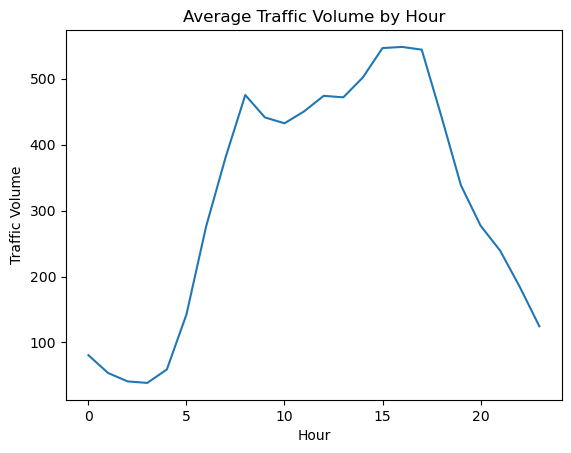

In [10]:
hourly_traffic = df.groupby("hour")["traffic_volume"].mean()

plt.figure()
hourly_traffic.plot(kind="line")
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic Volume")
plt.show()

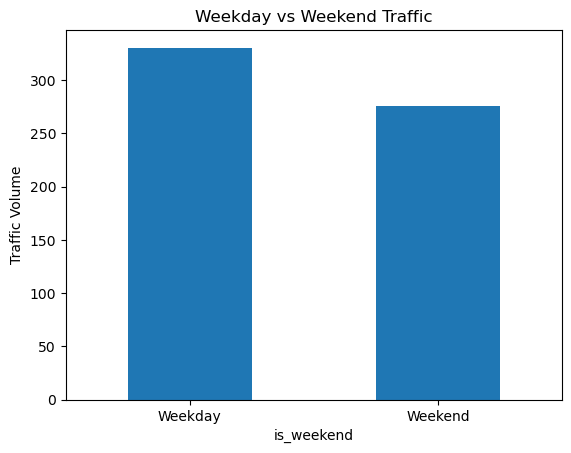

In [11]:
weekday_vs_weekend = df.groupby("is_weekend")["traffic_volume"].mean()

weekday_vs_weekend.plot(kind="bar")
plt.title("Weekday vs Weekend Traffic")
plt.xticks([0,1], ["Weekday", "Weekend"], rotation=0)
plt.ylabel("Traffic Volume")
plt.show()

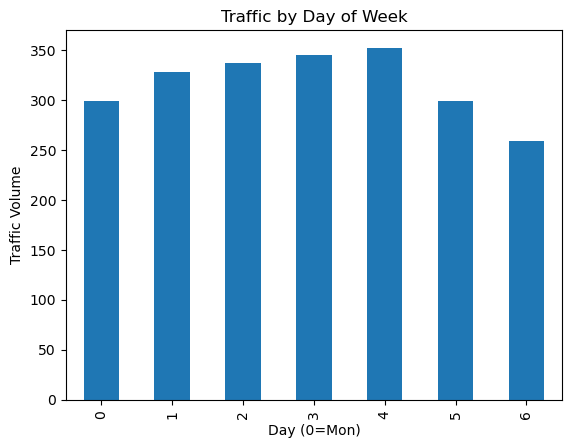

In [12]:
day_traffic = df.groupby("day_of_week")["traffic_volume"].mean()

day_traffic.plot(kind="bar")
plt.title("Traffic by Day of Week")
plt.xlabel("Day (0=Mon)")
plt.ylabel("Traffic Volume")
plt.show()

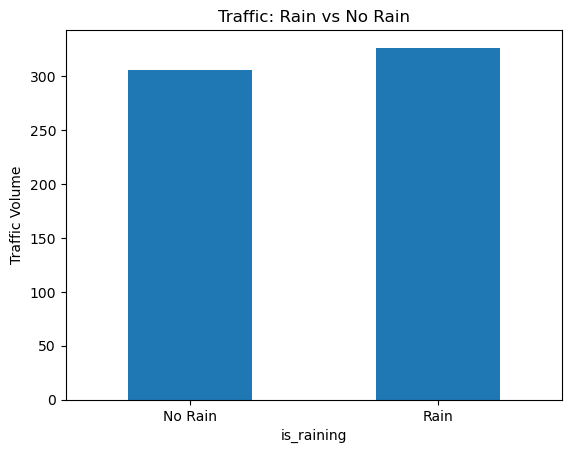

In [13]:
rain_vs_no_rain = df.groupby("is_raining")["traffic_volume"].mean()

rain_vs_no_rain.plot(kind="bar")
plt.xticks([0,1], ["No Rain", "Rain"], rotation=0)
plt.title("Traffic: Rain vs No Rain")
plt.ylabel("Traffic Volume")
plt.show()

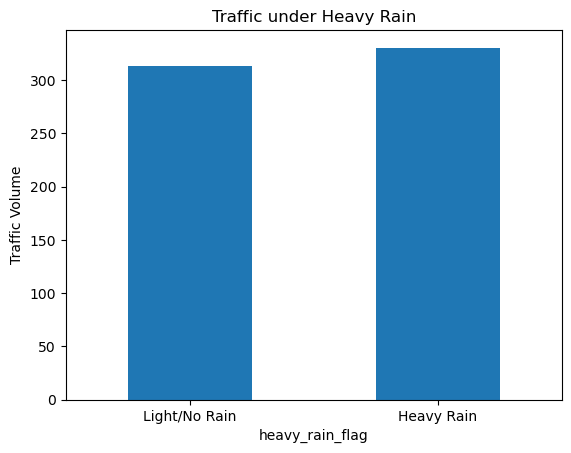

In [14]:
rain_levels = df.groupby("heavy_rain_flag")["traffic_volume"].mean()

rain_levels.plot(kind="bar")
plt.xticks([0,1], ["Light/No Rain", "Heavy Rain"], rotation=0)
plt.title("Traffic under Heavy Rain")
plt.ylabel("Traffic Volume")
plt.show()

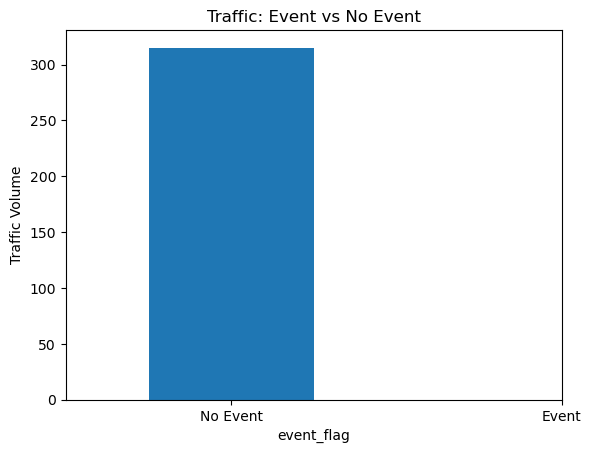

In [15]:
event_impact = df.groupby("event_flag")["traffic_volume"].mean()

event_impact.plot(kind="bar")
plt.xticks([0,1], ["No Event", "Event"], rotation=0)
plt.title("Traffic: Event vs No Event")
plt.ylabel("Traffic Volume")
plt.show()

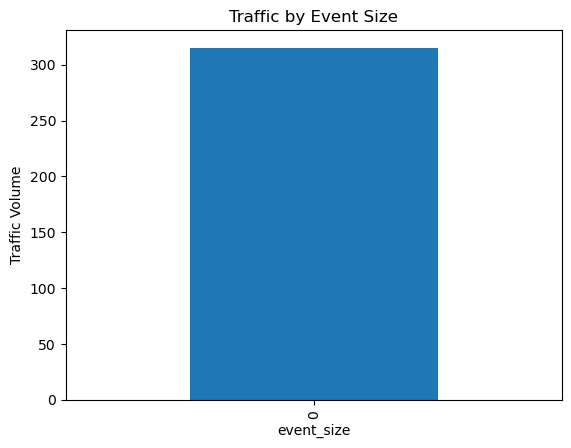

In [16]:
event_size_impact = df.groupby("event_size")["traffic_volume"].mean()

event_size_impact.plot(kind="bar")
plt.title("Traffic by Event Size")
plt.ylabel("Traffic Volume")
plt.show()

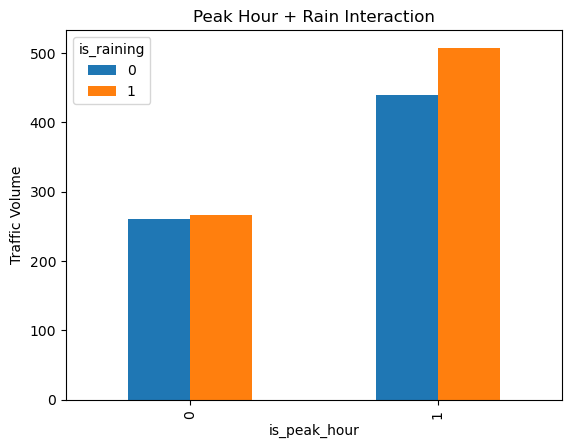

In [17]:
peak_rain = df.groupby(["is_peak_hour", "is_raining"])["traffic_volume"].mean().unstack()

peak_rain.plot(kind="bar")
plt.title("Peak Hour + Rain Interaction")
plt.ylabel("Traffic Volume")
plt.show()

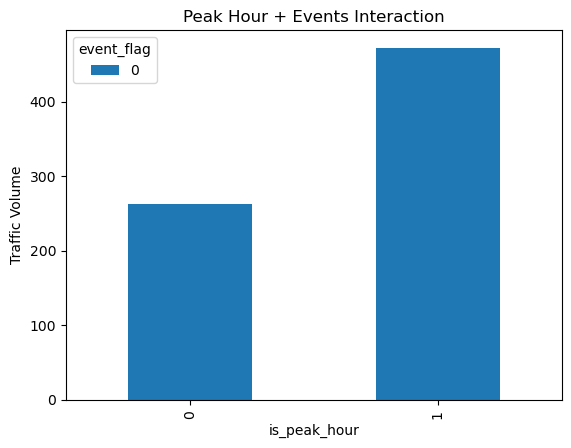

In [18]:
peak_event = df.groupby(["is_peak_hour", "event_flag"])["traffic_volume"].mean().unstack()

peak_event.plot(kind="bar")
plt.title("Peak Hour + Events Interaction")
plt.ylabel("Traffic Volume")
plt.show()